# Setup and download - Molecular cartography data from Legnini et al., 2023 

This tutorials shows how to set up an multiple slide molecular cartography dataset used from [Legnini et al., 2023](https://doi.org/10.1038/s41592-023-01986-w). To follow along with this and the following tutorials, please execute the following steps first:

- Set up InterScale environment (see instructions in ReadMe)
- Download the sample data from the original publication from [Zenodo](https://doi.org/10.5281/zenodo.6143560) under the accession no. 6143561

In [24]:
import scanpy as sc
import squidpy as sq
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import issparse
import seaborn as sns
from scipy.sparse import csr_array, csr_matrix, issparse

from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

In [58]:
import os

# LRZ home
if os.path.exists("/dss/dsshome1/05/di93tig"):
    print('LRZ cluster')
    CLUSTER = 'LRZ'
    BASE_DIR_REPO = "/dss/dsshome1/05/di93tig/1_projects/InterScale_reproducibility" 
    BASE_DIR_PROJECT = "/dss/dssfs03/tumdss/pn36po/pn36po-dss-0002/di93tig/Projects/A3_InterScale"
elif os.path.exists("/home/icb/francesca.drummer/"):
    print('HPC cluster')
    CLUSTER = 'HPC'
    BASE_DIR_REPO = "/home/icb/francesca.drummer/1-Projects/"
    BASE_DIR_PROJECT = ""
else:
    print('unkown')
    CLUSTER = 'unknown'
DATA = "legnini23"

LRZ cluster


In [26]:
import yaml
with open(os.path.join(BASE_DIR_REPO, "InterScale_reproducibility/figures/config.yml"), "r") as f:
    config = yaml.safe_load(f)

PALETTE = config["palettes"]["continuous"]
CELL_TYPE_COLORS = config["palettes"][DATA]
SLIDE_ID = config["slide_examples"][DATA]

<mark>TODO: Change data path</mark>

In [4]:
LRZ_LEGNINI23 = f'{BASE_DIR_PROJECT}/data/{DATA}.h5ad'  

## Load data

In [5]:
adata = sc.read_h5ad(LRZ_LEGNINI23)
adata

AnnData object with n_obs × n_vars = 43762 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names', 'split'
    var: 'gene_ids', 'feature_types'
    obsm: 'spatial'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw'

## SHH rings

In [11]:
from skimage.filters import threshold_otsu

def calculate_adaptive_threshold(adata_subset, gene):
    # Extract expression for the specific gene
    expr = adata_subset[:, gene].X
    if not isinstance(expr, np.ndarray):
        expr = expr.toarray().flatten()
    else:
        expr = expr.flatten()
    
    # Filter out absolute zeros to focus on potential signal
    positive_expr = expr[expr > 0]
    
    if len(positive_expr) == 0:
        return None
    
    # Calculate Otsu threshold on non-zero expression
    try:
        thresh = threshold_otsu(positive_expr)
    except:
        # Fallback to a high percentile if Otsu fails
        thresh = np.percentile(positive_expr, 95)
        
    return thresh

In [12]:
adata.obs['SHH_cats'] = 'Background'

for sample in adata.obs['sample'].unique():

#subset to slide
	sample_mask = adata.obs['sample'] == sample
	ctrl_test = adata[sample_mask].copy()

	#Cluster by distance
	gene_name = 'SHH'
	threshold = 50 # can depend on the slide? 

	if gene_name in ctrl_test.var_names:
		gene_expression = ctrl_test[:, gene_name].X
		if not isinstance(gene_expression, np.ndarray):
			gene_expression = gene_expression.toarray().flatten()  # For sparse matrices
		else:
			gene_expression = gene_expression.flatten()
			
		threshold=calculate_adaptive_threshold(ctrl_test, 'SHH')
		# Annotate cells in the obs field based on the expression threshold
		ctrl_test.obs[f'{gene_name}_status'] = np.where(gene_expression >= threshold, f'{gene_name}+', f'{gene_name}-')
	else:
		print(f"Gene '{gene_name}' not found in adata.var_names.")
	## Coordinates
	coords = ctrl_test.obsm["spatial"]
	shh_coords = coords[ctrl_test.obs["SHH_status"] == "SHH+"]

	## Compute distance to nearest SHH+ cell
	from scipy.spatial import cKDTree
	tree = cKDTree(shh_coords)
	dist, _ = tree.query(coords, k=1)
	ctrl_test.obs["dist_to_SHH+"] = dist

	## Cluster cells based on distance
	sc.pp.neighbors(ctrl_test, use_rep=None, n_neighbors=10)
	ctrl_test.obs["distance_cluster"] = np.digitize(ctrl_test.obs["dist_to_SHH+"], bins=[10, 20, 30])  # arbitrary cutoffs

	dist = ctrl_test.obs["dist_to_SHH+"].to_numpy()

	n_bins = 4
	edges = np.quantile(dist, np.linspace(0, 1, n_bins + 1))
	labels = [f"ring_{i+1}" for i in range(len(edges)-1)]

	cats = pd.cut(dist, bins=edges, labels=labels, include_lowest=True, duplicates="drop")
	# directly ensure it's ordered


	adata.obs.loc[sample_mask, 'SHH_cats'] = cats.astype(str)

         Falling back to preprocessing with `sc.pp.pca` and default params.
         Falling back to preprocessing with `sc.pp.pca` and default params.
         Falling back to preprocessing with `sc.pp.pca` and default params.
         Falling back to preprocessing with `sc.pp.pca` and default params.
         Falling back to preprocessing with `sc.pp.pca` and default params.
         Falling back to preprocessing with `sc.pp.pca` and default params.
         Falling back to preprocessing with `sc.pp.pca` and default params.
         Falling back to preprocessing with `sc.pp.pca` and default params.
         Falling back to preprocessing with `sc.pp.pca` and default params.
         Falling back to preprocessing with `sc.pp.pca` and default params.
         Falling back to preprocessing with `sc.pp.pca` and default params.
         Falling back to preprocessing with `sc.pp.pca` and default params.
         Falling back to preprocessing with `sc.pp.pca` and default params.
         Fal

In [53]:
slide_ids = list(SLIDE_ID.values())

In [48]:
values = [CELL_TYPE_COLORS[key] for key in ['ring_1', 'ring_2', 'ring_3', 'ring_4']]
adata.uns['SHH_cats_colors'] = values

In [59]:
f"{BASE_DIR_REPO}/figures/{DATA}/data_visualization/shh_rings_{slide_ids[0]}_{slide_ids[1]}.png"

'/dss/dsshome1/05/di93tig/1_projects/InterScale_reproducibility/figures/legnini23/data_visualization/shh_rings_slide4_A2-3_slide4_B2-2.png'

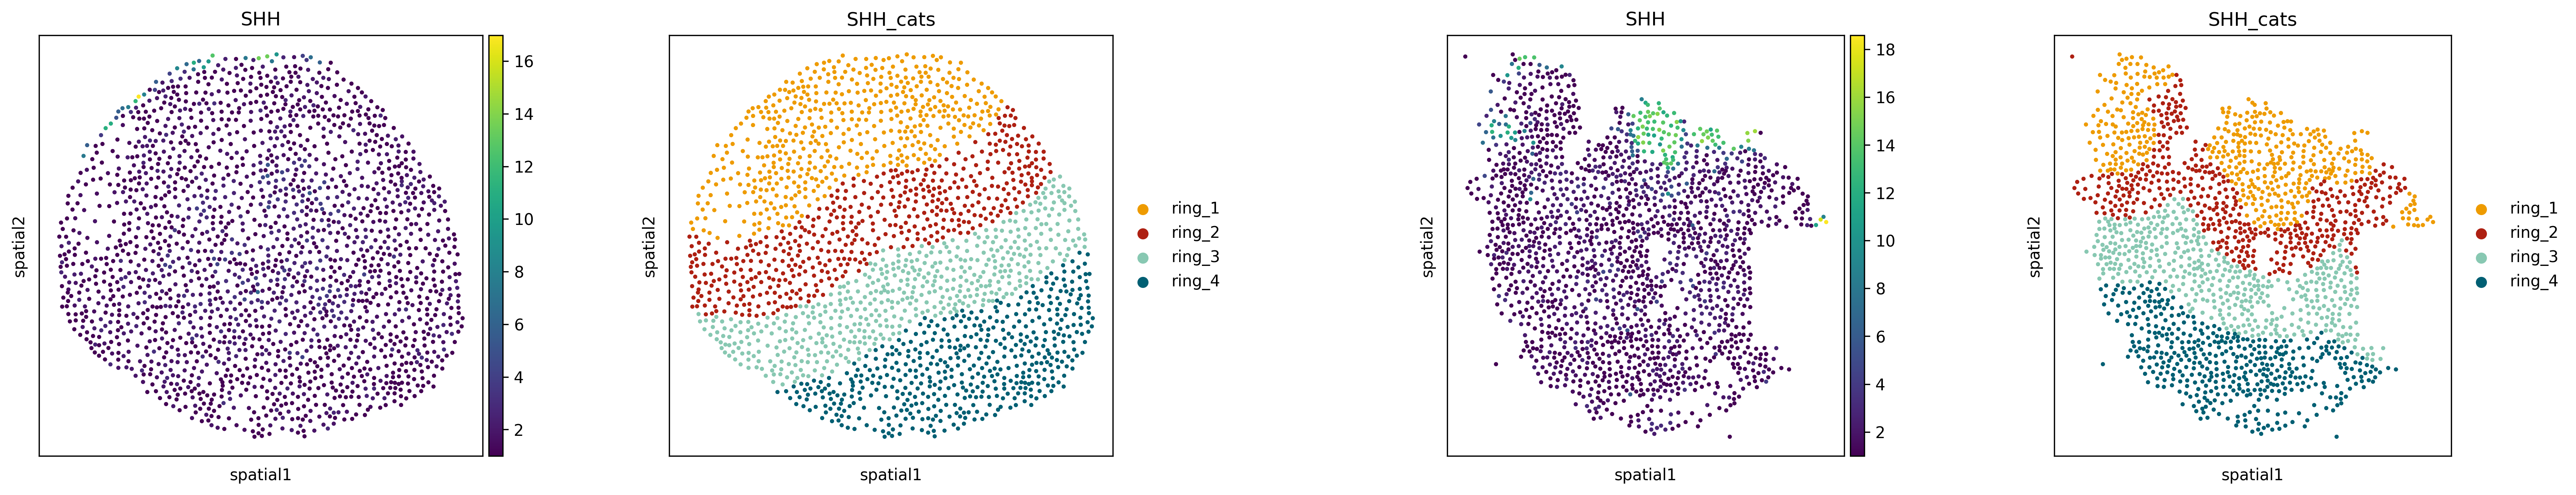

In [60]:
adata.X = adata.layers['norm_ftsqrt']
sq.pl.spatial_scatter(
        adata,
        library_key = 'sample',
        library_id = slide_ids,
        color = ['SHH', 'SHH_cats'],
        cmap = PALETTE,
        size = 10,
        shape= None,
        save=f"{BASE_DIR_REPO}/figures/{DATA}/data_visualization/shh_rings_{slide_ids[0]}_{slide_ids[1]}.png",
        dpi = 300)